In [1]:
import torchvision
from torchvision import datasets, models, transforms
import torch.nn as nn
from torchsummary import summary
import torch

## 1. Fine tuning di rete pre allenata, solo ultimo layer

In [2]:
model_ft = models.vgg16(weights='IMAGENET1K_V1') # modello preallenato che sfruttiamo

num_classes = 2 # task cat vs dog
num_ftrs = model_ft.classifier[6].in_features # sostituisco ultimo layer con nuovo
model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes) # cambio il numero finale di classi da predirre, numero task mio

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 156MB/s] 


In [3]:
# Ensure the model is on the correct device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_ft = model_ft.to(device)

# Use summary and specify the device
# torchsummary expects 'cuda' or 'cpu', not 'cuda:0'
summary(model_ft, (3, 224, 224), device='cuda' if torch.cuda.is_available() else 'cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [5]:
# Freeze all layers first
for param in model_ft.parameters():
  param.requires_grad = False

# Unfreeze the parameters of the last n layers of the classifier
# num_layers_to_unfreeze = 1 # warm up
num_layers_to_unfreeze = 7
for i in range(num_layers_to_unfreeze):
    # Access layers from the end of the classifier list
    for param in model_ft.classifier[- (i + 1)].parameters():
        param.requires_grad = True

summary(model_ft, (3, 224, 224)) # each row = layer

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

## 2. Download del dataset da Kaggle

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

100%|██████████| 218M/218M [00:00<00:00, 232MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1


## 3. Preparazione del dataset e creazione del file CSV delle annotazioni

In [9]:
import os
import pandas as pd
from pathlib import Path

# Definisci il percorso del dataset
dataset_path = path
train_path = os.path.join(dataset_path, 'training_set', 'training_set')
test_path = os.path.join(dataset_path, 'test_set', 'test_set')

# Funzione per creare il file CSV delle annotazioni
def create_annotations_csv(data_dir, output_csv):
    data = []

    # Cerca immagini di cani
    dogs_dir = os.path.join(data_dir, 'dogs')
    if os.path.exists(dogs_dir):
        for img_name in os.listdir(dogs_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                data.append({
                    'filename': os.path.join('dogs', img_name),
                    'label': 1  # 1 per cani
                })

    # Cerca immagini di gatti
    cats_dir = os.path.join(data_dir, 'cats')
    if os.path.exists(cats_dir):
        for img_name in os.listdir(cats_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                data.append({
                    'filename': os.path.join('cats', img_name),
                    'label': 0  # 0 per gatti
                })

    # Crea DataFrame e salva come CSV
    df = pd.DataFrame(data)
    df.to_csv(output_csv, index=False)
    print(f"Creato {output_csv} con {len(df)} immagini")
    print(f"Gatti: {len(df[df['label'] == 0])}, Cani: {len(df[df['label'] == 1])}")
    return df

# Crea i file CSV per training e test
train_annotations = create_annotations_csv(train_path, 'train_annotations.csv')
test_annotations = create_annotations_csv(test_path, 'test_annotations.csv')

Creato train_annotations.csv con 8005 immagini
Gatti: 4000, Cani: 4005
Creato test_annotations.csv con 2023 immagini
Gatti: 1011, Cani: 1012


## 4. Classe Dataset Personalizzata

In [10]:
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from PIL import Image
import torch
from torchvision import transforms

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        """
        Args:
            annotations_file: Percorso del file CSV con le annotazioni
            img_dir: Directory contenente le immagini
            transform: Trasformazioni da applicare alle immagini
            target_transform: Trasformazioni da applicare alle label
        """
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        # Ottieni il percorso dell'immagine
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])

        # Leggi l'immagine usando PIL (più compatibile)
        image = Image.open(img_path).convert('RGB')

        # Ottieni la label
        label = self.img_labels.iloc[idx, 1]

        # Applica le trasformazioni
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)

        return image, label

## 5. Definizione delle trasformazioni

In [ ]:
# Definisci le trasformazioni per le immagini di TRAINING con data augmentation
transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Crop casuale tra 80-100%
    transforms.RandomHorizontalFlip(p=0.5),  # Flip orizzontale
    transforms.RandomRotation(15),  # Rotazione casuale ±15 gradi
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Variazioni colore
    transforms.RandomGrayscale(p=0.1),  # 10% probabilità di grayscale
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Trasformazioni per VALIDATION e TEST (NO augmentation, solo preprocessing)
test_transform = transforms.Compose([
    transforms.Resize(256),  # Ridimensiona lato più corto a 256
    transforms.CenterCrop(224),  # Crop centrale 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 6. Creazione dei Dataset e DataLoader

In [13]:
# Crea i dataset
train_dataset = CustomImageDataset(
    annotations_file='train_annotations.csv',
    img_dir=train_path,
    transform=transform
)

test_dataset = CustomImageDataset(
    annotations_file='test_annotations.csv',
    img_dir=test_path,
    transform=test_transform
)

# Crea i DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training samples: 8005
Test samples: 2023
Batch size: 32
Training batches: 251
Test batches: 64


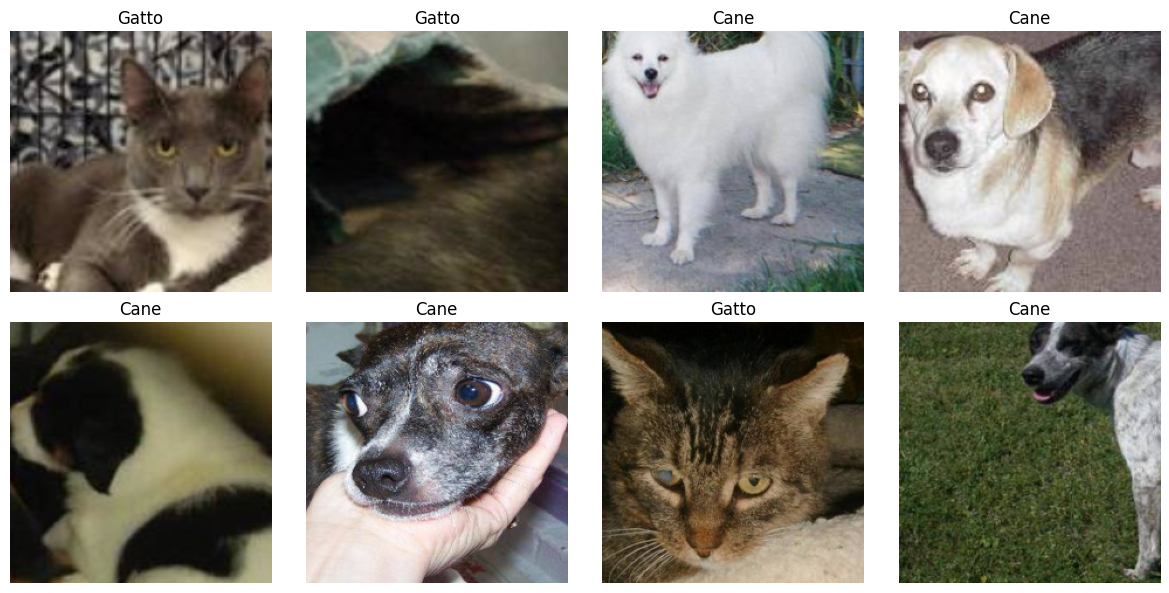

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Funzione per denormalizzare le immagini
def denormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

# Ottieni un batch di immagini
images, labels = next(iter(train_loader))

# Visualizza le prime 8 immagini
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for idx in range(8):
    # Denormalizza l'immagine
    img = images[idx].clone()
    img = denormalize(img)
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    # Visualizza
    axes[idx].imshow(img)
    axes[idx].set_title(f"{'Gatto' if labels[idx] == 0 else 'Cane'}")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Test di un singolo elemento
sample_image, sample_label = train_dataset[0]
print(f"Forma dell'immagine: {sample_image.shape}")
print(f"Label: {sample_label} ({'Gatto' if sample_label == 0 else 'Cane'})")
print(f"Tipo di dato: {sample_image.dtype}")
print(f"Min value: {sample_image.min():.3f}")
print(f"Max value: {sample_image.max():.3f}")

In [ ]:
# Calcola le statistiche del dataset
def calculate_dataset_stats(dataset):
    labels = []
    for _, label in dataset:
        labels.append(label)

    labels = np.array(labels)
    unique, counts = np.unique(labels, return_counts=True)

    print("Distribuzione delle classi:")
    for i, count in zip(unique, counts):
        class_name = 'Gatti' if i == 0 else 'Cani'
        percentage = (count / len(labels)) * 100
        print(f"  {class_name}: {count} ({percentage:.1f}%)")

    return unique, counts

print("=== Training Set ===")
train_unique, train_counts = calculate_dataset_stats(train_dataset)

print("\n=== Test Set ===")
test_unique, test_counts = calculate_dataset_stats(test_dataset)

# Visualizza la distribuzione
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(['Gatti', 'Cani'], train_counts, color=['blue', 'orange'])
ax1.set_title('Training Set')
ax1.set_ylabel('Numero di immagini')

ax2.bar(['Gatti', 'Cani'], test_counts, color=['blue', 'orange'])
ax2.set_title('Test Set')
ax2.set_ylabel('Numero di immagini')

plt.tight_layout()
plt.show()

# 10. Training Setup


In [14]:
import torch.optim as optim


# Device configuration
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move model to device
model_ft = model_ft.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer - only parameters with requires_grad=True
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=0.001
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

print("✓ Training setup complete")
print(f"  - Loss: CrossEntropyLoss")
print(f"  - Optimizer: Adam (lr=0.001)")
print(f"  - Scheduler: StepLR (step_size=7, gamma=0.1)")

Using device: cuda:0
✓ Training setup complete
  - Loss: CrossEntropyLoss
  - Optimizer: Adam (lr=0.001)
  - Scheduler: StepLR (step_size=7, gamma=0.1)


# 11. Training Function


In [15]:
def train_model(model, criterion, optimizer, scheduler, dataloaders, num_epochs=10):
    """
    Train the model and return training history

    Args:
        model: PyTorch model
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        dataloaders: Dictionary with 'train' and 'val' dataloaders
        num_epochs: Number of training epochs

    Returns:
        model: Trained model
        history: Dictionary with training history
    """
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Dictionary to store loss and accuracy
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 60)

        # Each epoch has training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = dataloaders['train']
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = dataloaders['val']

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            pbar = tqdm(dataloader, desc=f'{phase.capitalize()} ')
            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # Update progress bar
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            if phase == 'train':
                scheduler.step()

            # Calculate epoch statistics
            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Save to history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            # Deep copy the best model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'✓ New best model! Validation Accuracy: {best_acc:.4f}')

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best Validation Accuracy: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

print("✓ Training function defined")

✓ Training function defined


# 12. Prepare DataLoaders Dictionary


In [16]:
from torch.utils.data import random_split

# Split train_dataset into train and validation (80/20 split)
train_size = int(0.87 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

# Create dataloaders
train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

# Create dataloaders dictionary
dataloaders = {
    'train': train_loader,
    'val': val_loader,
    'test': test_loader
}

print("✓ DataLoaders dictionary created")
print(f"  - Train samples: {len(train_subset)}")
print(f"  - Validation samples: {len(val_subset)}")
print(f"  - Test samples: {len(test_dataset)}")
print(f"  - Batch size: {batch_size}")
print(f"  - Train batches: {len(train_loader)}")
print(f"  - Validation batches: {len(val_loader)}")
print(f"  - Test batches: {len(test_loader)}")

✓ DataLoaders dictionary created
  - Train samples: 6964
  - Validation samples: 1041
  - Test samples: 2023
  - Batch size: 32
  - Train batches: 218
  - Validation batches: 33
  - Test batches: 64


# 13. Train the Model (Feature Extraction)


In [ ]:
import time
import copy
from tqdm import tqdm


print("=" * 60)
print("PHASE 1: Feature Extraction (only last layer trainable)")
print("=" * 60)

num_epochs_feature_extraction = 10

model_ft_trained, history_ft = train_model(
    model_ft,
    criterion,
    optimizer_ft,
    scheduler,
    dataloaders,
    num_epochs=num_epochs_feature_extraction
)

PHASE 1: Feature Extraction (only last layer trainable)

Epoch 1/10
------------------------------------------------------------


Train : 100%|██████████| 218/218 [00:44<00:00,  4.88it/s, loss=0.0293]


Train Loss: 0.3778 Acc: 0.9176


Val : 100%|██████████| 33/33 [00:05<00:00,  5.99it/s, loss=0.0992]


Val Loss: 0.3253 Acc: 0.9212
✓ New best model! Validation Accuracy: 0.9212

Epoch 2/10
------------------------------------------------------------


...

Train : 100%|██████████| 218/218 [00:44<00:00,  4.87it/s, loss=0.1857]


Train Loss: 0.1905 Acc: 0.9393


Val : 100%|██████████| 33/33 [00:05<00:00,  5.93it/s, loss=0.0460]


Val Loss: 0.1381 Acc: 0.9481

Epoch 5/10
------------------------------------------------------------


Train :  81%|████████  | 177/218 [00:36<00:08,  4.99it/s, loss=0.3477]

# 14. Plot Training History


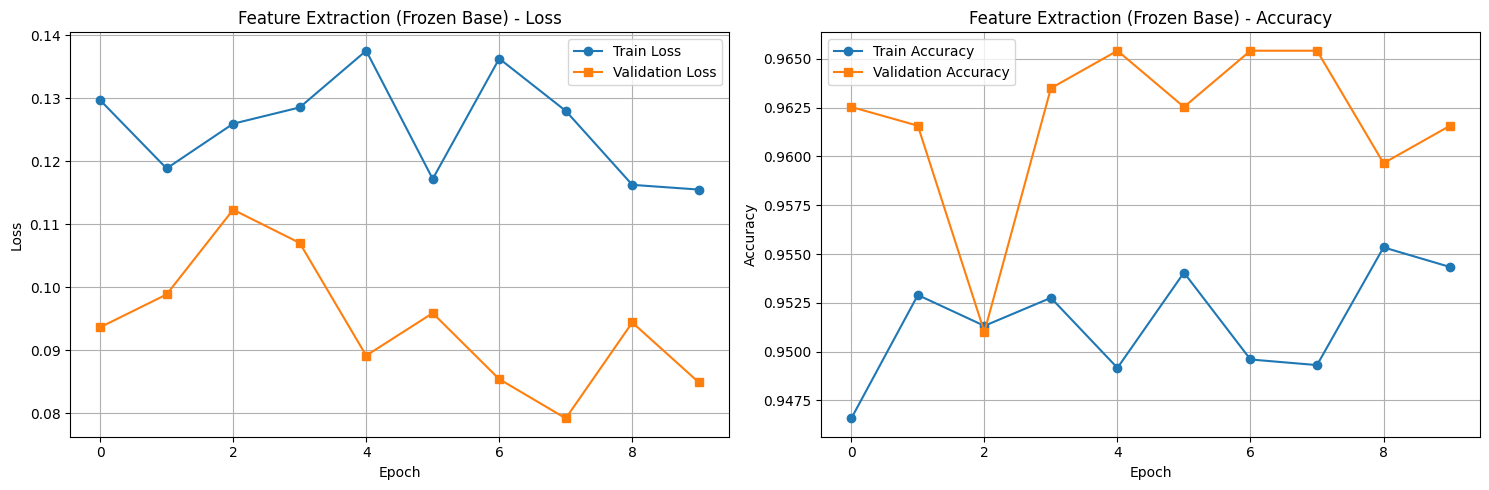

In [ ]:
def plot_training_history(history, title='Training History'):
    """Plot training and validation loss and accuracy"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['val_loss'], label='Validation Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy plot
    ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
    ax2.plot(history['val_acc'], label='Validation Accuracy', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history_ft, 'Feature Extraction (Frozen Base)')

# 15. Test Set Evaluation Function

In [ ]:
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def test_model(model, dataloader, device):
    """
    Test the model on test set

    Args:
        model: Trained PyTorch model
        dataloader: Test DataLoader
        device: Device to run evaluation on
    """
    model.eval()
    test_loss = 0
    correct = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, target in tqdm(dataloader, desc='Testing'):
            batch_size_current = data.shape[0]
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()

            pred = output.argmax(dim=1, keepdim=True)

            # Sanity check
            pred = pred.view(batch_size_current)
            target = target.view(batch_size_current)

            # Compute prediction ok
            batch_pred_ok = pred.eq(target).sum().item()
            correct += batch_pred_ok

            # Store predictions and labels
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    test_loss /= len(dataloader.dataset)
    num_samples = len(dataloader.dataset)
    test_accuracy = correct / num_samples

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(dataloader.dataset),
        100. * test_accuracy))

    return test_accuracy, all_preds, all_labels

print("✓ Test function defined")

✓ Test function defined


# 16. Detailed Evaluation with Metrics

In [ ]:
def detailed_evaluation(all_labels, all_preds):
    """
    Show detailed evaluation metrics

    Args:
        all_labels: True labels
        all_preds: Predicted labels
    """
    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=['Cats', 'Dogs']))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Cats', 'Dogs'],
                yticklabels=['Cats', 'Dogs'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

print("✓ Detailed evaluation function defined")

✓ Detailed evaluation function defined


# 17. Final Test Set Evaluation

FINAL EVALUATION ON TEST SET - Feature Extraction


Testing: 100%|██████████| 64/64 [00:12<00:00,  5.08it/s]



Test set: Average loss: 0.1001, Accuracy: 1944/2023 (96.09%)


Classification Report:
              precision    recall  f1-score   support

        Cats       0.96      0.96      0.96      1011
        Dogs       0.96      0.96      0.96      1012

    accuracy                           0.96      2023
   macro avg       0.96      0.96      0.96      2023
weighted avg       0.96      0.96      0.96      2023



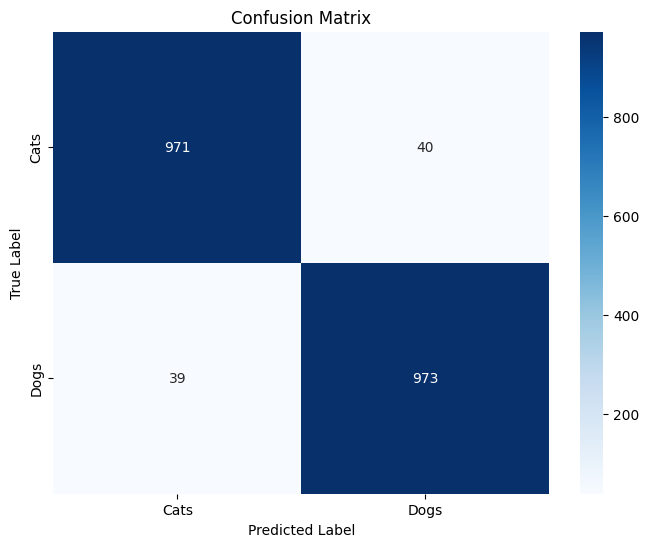


FINAL RESULTS:
  - Best Validation Accuracy: 0.9654
  - Final Test Accuracy: 0.9609


In [ ]:
print("=" * 60)
print("FINAL EVALUATION ON TEST SET - Feature Extraction")
print("=" * 60)

# Test on the test set
test_accuracy, test_preds, test_labels = test_model(
    model_ft_trained,
    dataloaders['test'],
    device
)

# Show detailed metrics
detailed_evaluation(test_labels, test_preds)

print(f"\n{'='*60}")
print(f"FINAL RESULTS:")
print(f"  - Best Validation Accuracy: {max(history_ft['val_acc']):.4f}")
print(f"  - Final Test Accuracy: {test_accuracy:.4f}")
print(f"{'='*60}")